## Xử lý ngôn ngữ tự nhiên - CS221.Q11.KHTN
### Chương 7: Large Language Model

#### Nhóm 2:
- Võ Lê Ngọc Thịnh - 24521710
- Vũ Minh Phương - 24521421
- Nguyễn Hồng Phúc - 24521390


In [26]:
import torch
import torch.nn.functional as F
import numpy as np
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [27]:
model_name = 'gpt2'
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Generation and Sampling

In [28]:
text = "Hello, I'm a language model,"
inputs = tokenizer(text, return_tensors='pt')

In [29]:
with torch.no_grad():
    outputs = model(**inputs)
    next_token_logits = outputs.logits[0, -1, :]

def get_probabilities(logits: torch.Tensor, temperature: float):
    scaled_logits = logits / temperature
    return F.softmax(scaled_logits, dim=-1)

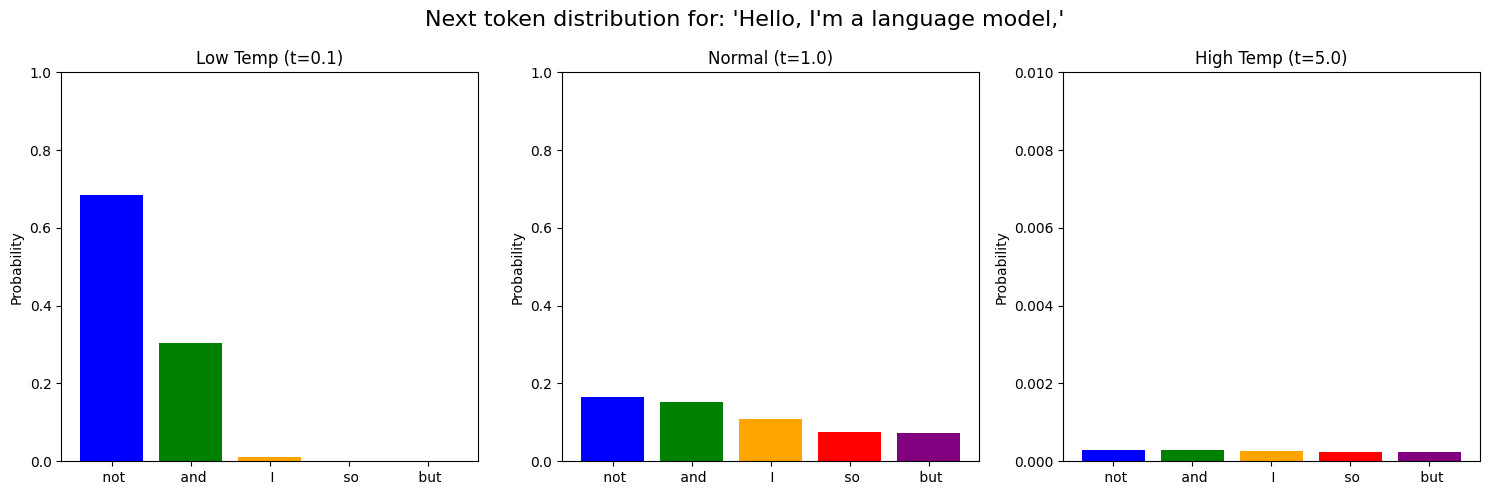

In [30]:
temperatures = [0.1, 1.0, 5.0]
titles = ["Low Temp (t=0.1)", "Normal (t=1.0)", "High Temp (t=5.0)"]

normal_probs = get_probabilities(next_token_logits, temperature=0.1)
top_probs, top_indices = torch.topk(normal_probs, 5)
top_tokens = [tokenizer.decode([idx.item()]) for idx in top_indices]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Next token distribution for: '{text}'", fontsize=16)

for i, tau in enumerate(temperatures):
    probs = get_probabilities(next_token_logits, tau)
    selected_probs = [probs[idx].item() for idx in top_indices]

    axes[i].bar(top_tokens, selected_probs, color=['blue', 'green', 'orange', 'red', 'purple'])
    axes[i].set_title(titles[i])
    axes[i].set_ylabel("Probability")
    if (tau <= 1.0):
      axes[i].set_ylim(0, 1.0)
    else:
      axes[i].set_ylim(0, 0.01)

plt.tight_layout()
plt.show()

In [31]:
def generate_multiple_samples(text, max_tokens, temperature, num_samples=3):
    print(f"=== Temperature: {temperature} | Generating {num_samples} samples ===")
    input_ids = tokenizer.encode(text, return_tensors='pt')
    outputs = model.generate(
        input_ids,
        max_new_tokens=max_tokens,
        temperature=temperature,
        do_sample=True,
        top_k=50,
        pad_token_id=tokenizer.eos_token_id,
        num_return_sequences=num_samples
    )
    for i, output in enumerate(outputs):
        generated_text = tokenizer.decode(output, skip_special_tokens=True)
        print(f"  [Sample {i+1}]: {generated_text}")
    print("-" * 70)

prompt = "The future of Artificial Intelligence is"

generate_multiple_samples(prompt, max_tokens=25, temperature=0.1, num_samples=3)
generate_multiple_samples(prompt, max_tokens=25, temperature=0.7, num_samples=3)
generate_multiple_samples(prompt, max_tokens=25, temperature=5.0, num_samples=3)

=== Temperature: 0.1 | Generating 3 samples ===
  [Sample 1]: The future of Artificial Intelligence is in the hands of the next generation of AI.

The future of Artificial Intelligence is in the hands of the next generation
  [Sample 2]: The future of Artificial Intelligence is in the hands of the next generation of AI researchers.

The future of Artificial Intelligence is in the hands of the next
  [Sample 3]: The future of Artificial Intelligence is in the hands of the next generation of AI.

The future of Artificial Intelligence is in the hands of the next generation
----------------------------------------------------------------------
=== Temperature: 0.7 | Generating 3 samples ===
  [Sample 1]: The future of Artificial Intelligence is still unclear. And for now, there are some signs of progress:

AI can be a very disruptive force in the
  [Sample 2]: The future of Artificial Intelligence is at hand, and the future is in the hands of the people.

The future is in the hands of the 

### Prompting Strategies

In [32]:
def generate_response(prompt_text, max_new_tokens=10, temperature=0.1):
    input_ids = tokenizer.encode(prompt_text, return_tensors='pt')
    output = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )
    full_text = tokenizer.decode(output[0], skip_special_tokens=True)
    return full_text

In [33]:
print("==== 1. ZERO-SHOT PROMPTING ====")
zero_shot_prompt = """Review: The food was absolutely disgusting and cold.
Format:"""

print(f"Prompt:\n{zero_shot_prompt}")
print("\nGenerated Output:")
print(generate_response(zero_shot_prompt))

print("\n" + "="*60 + "\n")

print("==== 2. FEW-SHOT PROMPTING ====")
few_shot_prompt = """Review: I loved the movie, the acting was fantastic!
Format: [+++]

Review: The customer service was terrible and rude.
Format: [---]

Review: This is the best phone I have ever bought.
Format: [+++]

Review: The food was absolutely disgusting and cold.
Format:"""

print(f"Prompt:\n{few_shot_prompt}")
print("\nGenerated Output:")
print(generate_response(few_shot_prompt))

==== 1. ZERO-SHOT PROMPTING ====
Prompt:
Review: The food was absolutely disgusting and cold.
Format:

Generated Output:
Review: The food was absolutely disgusting and cold.
Format: A small bowl of soup with a few slices of


==== 2. FEW-SHOT PROMPTING ====
Prompt:
Review: I loved the movie, the acting was fantastic!
Format: [+++]

Review: The customer service was terrible and rude.
Format: [---]

Review: This is the best phone I have ever bought.
Format: [+++]

Review: The food was absolutely disgusting and cold.
Format:

Generated Output:
Review: I loved the movie, the acting was fantastic!
Format: [+++]

Review: The customer service was terrible and rude.
Format: [---]

Review: This is the best phone I have ever bought.
Format: [+++]

Review: The food was absolutely disgusting and cold.
Format: [---]

Review: The movie was


### Thực nghiệm Phân loại Cảm xúc với Kiến trúc Encoder (BERT)

Thực nghiệm này minh họa sự khác biệt cốt lõi giữa hai loại kiến trúc ngôn ngữ lớn:

* **Kiến trúc**: Khác với Decoder (như GPT) dùng để sinh văn bản, **BERT là một Encoder**. Nó không được dùng để "nói" mà dùng để tạo ra các vector biểu diễn cho việc "hiểu" văn bản.
* **Classification Head**: Trong bài này, chúng ta không dùng LM Head (dự đoán từ bị che) mà gắn một **Classification Head** lên trên token `[CLS]` để phân loại cảm xúc.
* **Finetuning**: Chúng ta thực hiện quá trình thích ứng mô hình đã pretrained sang một tác vụ cụ thể bằng cách huấn luyện trên dữ liệu có nhãn (supervised data).
* **Dataset**: Sử dụng bộ dữ liệu **IMDb** tiêu chuẩn để đảm bảo tính ổn định và khách quan trong đánh giá.

In [34]:
!pip install transformers datasets torch pyvi

In [35]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset

In [36]:
dataset = load_dataset("imdb")
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [37]:
def preprocess_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

print("Đang tiền xử lý dữ liệu...")
tokenized_datasets = dataset.map(preprocess_function, batched=True)
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Đang tiền xử lý dữ liệu...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [38]:
train_loader = DataLoader(tokenized_datasets["train"].shuffle(seed=42).select(range(500)), batch_size=16)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

print(f"Bắt đầu Finetuning trên {device}...")
model.train()
for epoch in range(20):
    print(f'Epoch {epoch}:')
    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        if i % 10 == 0:
            print(f"Batch {i}, Loss: {loss.item():.4f}")

print("Finetuning hoàn tất!")

Bắt đầu Finetuning trên cuda...
Epoch 0:
Batch 0, Loss: 0.6560
Batch 10, Loss: 0.6650
Batch 20, Loss: 0.7562
Batch 30, Loss: 0.6665
Epoch 1:
Batch 0, Loss: 0.5821
Batch 10, Loss: 0.5590
Batch 20, Loss: 0.5379
Batch 30, Loss: 0.4716
Epoch 2:
Batch 0, Loss: 0.7416
Batch 10, Loss: 0.3042
Batch 20, Loss: 0.2939
Batch 30, Loss: 0.1380
Epoch 3:
Batch 0, Loss: 0.6645
Batch 10, Loss: 0.1157
Batch 20, Loss: 0.2710
Batch 30, Loss: 0.0481
Epoch 4:
Batch 0, Loss: 0.5138
Batch 10, Loss: 0.2185
Batch 20, Loss: 0.4021
Batch 30, Loss: 0.0821
Epoch 5:
Batch 0, Loss: 0.3512
Batch 10, Loss: 0.0193
Batch 20, Loss: 0.2487
Batch 30, Loss: 0.0170
Epoch 6:
Batch 0, Loss: 0.1598
Batch 10, Loss: 0.0097
Batch 20, Loss: 0.2152
Batch 30, Loss: 0.0115
Epoch 7:
Batch 0, Loss: 0.0133
Batch 10, Loss: 0.0066
Batch 20, Loss: 0.1730
Batch 30, Loss: 0.0074
Epoch 8:
Batch 0, Loss: 0.0068
Batch 10, Loss: 0.0052
Batch 20, Loss: 0.0794
Batch 30, Loss: 0.0066
Epoch 9:
Batch 0, Loss: 0.0251
Batch 10, Loss: 0.0042
Batch 20, Loss

In [39]:
model.eval()
test_loader = DataLoader(tokenized_datasets["test"].shuffle(seed=42).select(range(100)), batch_size=16)
correct = 0
total = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

print(f"\nĐộ chính xác trên tập Test: {correct/total:.2%}")


Độ chính xác trên tập Test: 84.00%
